In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("C:/Data_Analyst_Journey/Luke Barousse/job_postings_flat.csv")

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
year = 2024
df = df[df['job_posted_date'].dt.year == year]

job = 'Data Analyst'
country = 'United States'

df_selected = df[(df['job_title_short']==job) & (df['job_country']==country)].copy()
df_selected['job_posted_month'] = df_selected['job_posted_date'].dt.month


df_exploded = df_selected.explode('job_skills')
df_skills_grouped = df_exploded.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_skills_grouped.loc['Total'] = df_skills_grouped.sum()
df_skills_grouped = df_skills_grouped[df_skills_grouped.loc['Total'].sort_values(ascending=False).index]
df_skills_grouped = df_skills_grouped.drop('Total')


df_month_total = df_selected.groupby('job_posted_month').size()
df_skills_grouped = df_skills_grouped.div(df_month_total / 100, axis=0)


df_skills_grouped = df_skills_grouped.reset_index()
df_skills_grouped['month'] = df_skills_grouped['job_posted_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_skills_grouped.set_index('month', inplace=True)
df_skills_grouped = df_skills_grouped.drop('job_posted_month', axis=1)

top_skills = 5
df_plot = df_skills_grouped.iloc[:,:top_skills]

df_plot

job_skills,sql,excel,python,tableau,power bi
month,,,,,
Jan,48.148148,34.236676,27.732611,25.813008,17.005420
Feb,49.428843,35.959067,30.009519,27.701095,18.491195
Mar,47.819851,39.500861,27.567413,26.649455,17.785427
Apr,48.284467,46.225827,27.760449,26.824704,18.683718
May,50.148017,45.174660,28.211960,26.583777,19.508585
Jun,50.273224,42.333655,30.408229,29.733205,19.607843
Jul,50.981975,41.323648,30.131827,27.522195,19.881625
Aug,52.116651,40.780809,29.115710,25.047037,18.603010
Sep,47.645889,39.389920,29.542440,25.165782,18.169761


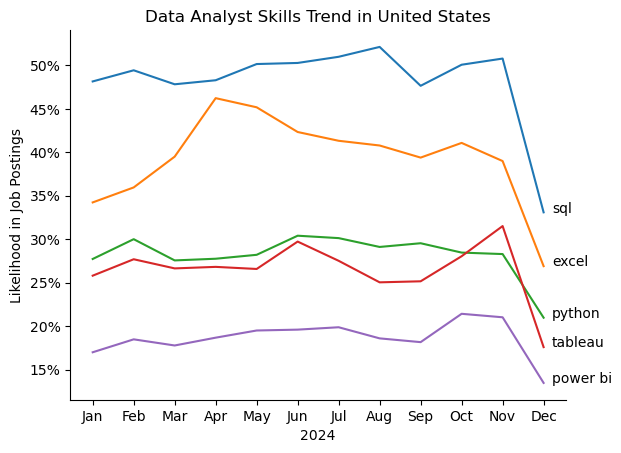

In [7]:
sns.lineplot(data=df_plot, dashes=False)
sns.despine()
plt.xlabel(year)
plt.ylabel('Likelihood in Job Postings')
plt.title(f'{job} Skills Trend in {country}')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y:.0f}%'))
plt.legend().remove()

for i in range(top_skills):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])